# Chapter 8: Extensive Model Evaluation & Validation

## Objective

In previous chapters, we completed:

- Data preprocessing
- Feature engineering
- Feature selection
- Baseline model training
- Hyperparameter tuning
- Final model selection

This notebook performs an extensive evaluation of the final tuned XGBoost and LightGBM classifiers.

Unlike model training, this chapter focuses on validating model quality from both technical and business perspectives.

The evaluation includes:

- Classification metrics
- Confusion matrix analysis
- ROC-AUC analysis
- Precision-Recall analysis
- Prediction confidence
- Error analysis
- Business interpretation for IFRS 9

This notebook serves as the final model validation report before model explainability (SHAP) and deployment.

In [1]:
# ============================================================
# Chapter 8 : Extensive Model Evaluation
# Import Required Libraries
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

from sklearn.preprocessing import label_binarize
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent      #  notebook is inside notebooks/
DATA_DIR = PROJECT_ROOT / "data"
MODEL_DIR = PROJECT_ROOT / "models"

MODEL_DIR.mkdir(exist_ok=True)

plt.style.use("seaborn-v0_8")
sns.set_palette("deep")

***Load Saved Models & Test Data***

In [4]:
# ============================================================
# Load Final Models
# ============================================================

lgbm_model = joblib.load(MODEL_DIR / "final_lgbm_model.pkl")
xgb_model = joblib.load(MODEL_DIR / "final_xgb_model.pkl")

# ============================================================
# Load Train/Test Data
# ============================================================

X_train = pd.read_csv(DATA_DIR / "processed/base_X_train.csv")
y_train = pd.read_csv(DATA_DIR / "processed/base_y_train.csv").squeeze()

X_test = pd.read_csv(DATA_DIR / "processed/base_X_test.csv")
y_test = pd.read_csv(DATA_DIR / "processed/base_y_test.csv").squeeze()

print(f"X_train : {X_train.shape}")
print(f"y_train : {y_train.shape}")

print(f"X_test  : {X_test.shape}")
print(f"y_test  : {y_test.shape}")

X_train : (40972, 56)
y_train : (40972,)
X_test  : (10243, 56)
y_test  : (10243,)


- We transformed y_train and y_test to Series as it is a requirement for scikit-learn metric functions

In [5]:
# ============================================================
# Generate Predictions
# ============================================================

# Predicted classes
xgb_pred = xgb_model.predict(X_test)
lgbm_pred = lgbm_model.predict(X_test)

# Predicted probabilities
xgb_proba = xgb_model.predict_proba(X_test)
lgbm_proba = lgbm_model.predict_proba(X_test)

print("XGBoost Prediction Shape :", xgb_pred.shape)
print("LightGBM Prediction Shape:", lgbm_pred.shape)

print("\nXGBoost Probability Shape :", xgb_proba.shape)
print("LightGBM Probability Shape:", lgbm_proba.shape)

XGBoost Prediction Shape : (10243,)
LightGBM Prediction Shape: (10243,)

XGBoost Probability Shape : (10243, 4)
LightGBM Probability Shape: (10243, 4)


**The probability matrices will be used later for:**

- ROC-AUC analysis
- Precision–Recall curves
- Confidence analysis
- Error analysis

# Overall Performance Metrics

The first step in model validation is to compare the overall predictive performance of the final tuned models.

We evaluate both XGBoost and LightGBM using multiple classification metrics rather than relying solely on accuracy. This provides a more comprehensive assessment of model performance, particularly in a multi-class credit risk classification problem.

The following metrics are reported:

- Accuracy
- Precision (Weighted)
- Recall (Weighted)
- F1-Score (Weighted)
- ROC-AUC (One-vs-Rest, Weighted)

These metrics provide an overall summary before proceeding to class-wise and error-specific analyses.

In [6]:
# ============================================================
# Overall Performance Metrics
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# -------------------------------
# XGBoost Metrics
# -------------------------------

xgb_metrics = {
    "Accuracy": accuracy_score(y_test, xgb_pred),
    "Precision": precision_score(y_test, xgb_pred, average="weighted"),
    "Recall": recall_score(y_test, xgb_pred, average="weighted"),
    "F1 Score": f1_score(y_test, xgb_pred, average="weighted"),
    "ROC-AUC": roc_auc_score(
        y_test,
        xgb_proba,
        multi_class="ovr",
        average="weighted"
    )
}

# -------------------------------
# LightGBM Metrics
# -------------------------------

lgbm_metrics = {
    "Accuracy": accuracy_score(y_test, lgbm_pred),
    "Precision": precision_score(y_test, lgbm_pred, average="weighted"),
    "Recall": recall_score(y_test, lgbm_pred, average="weighted"),
    "F1 Score": f1_score(y_test, lgbm_pred, average="weighted"),
    "ROC-AUC": roc_auc_score(
        y_test,
        lgbm_proba,
        multi_class="ovr",
        average="weighted"
    )
}

# -------------------------------
# Comparison Table
# -------------------------------

comparison_df = pd.DataFrame(
    {
        "XGBoost": xgb_metrics,
        "LightGBM": lgbm_metrics
    }
).T.round(4)

comparison_df

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
XGBoost,0.7930,0.7739,0.7930,0.7805,0.9287
LightGBM,0.7952,0.7750,0.7952,0.7814,0.9284


In [8]:
comparison_df.style.highlight_max(
    axis=0,
    color="#DC7413",
    subset=comparison_df.columns
).format("{:.4f}")

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
XGBoost,0.7930,0.7739,0.7930,0.7805,0.9287
LightGBM,0.7952,0.7750,0.7952,0.7814,0.9284


- We see most of the metrics the scores are almost similar with LightGBM having slightly better results, except for ROC-AUC value where XGBoost is better 
**Observations**
1. Both models perform almost identically

The differences are extremely small:

Accuracy difference = `0.22%`                                                                                           
F1 difference = `0.09%`                                                                                         
ROC-AUC difference = `0.03%`                                                                                    

This suggests that both tuned models have converged to a very similar level of predictive performance on your dataset.

An `ROC-AUC above 0.90` for a four-class credit rating problem indicates strong discriminative ability.

This means the models can effectively distinguish among applicants belonging to different internal risk grades (P1–P4).

**Why use weighted averages?**

- Since your target consists of four credit rating classes (P1–P4), weighted averaging is preferred because it accounts for class imbalance.

`Macro average` treats all classes equally.
- Weighted average accounts for the number of samples in each class.

- For our project, weighted metrics are the primary metrics to report because they better reflect overall production performance. Later, the classification report will include both macro and weighted averages for a complete picture.

### ***Next Section: Classification Report***

Overall metrics provide a high-level summary of model performance but do not reveal how well each individual credit risk grade is classified.

To gain deeper insight, we evaluate Precision, Recall, and F1-score for each class separately.

The classification report helps answer questions such as:

- Which risk grades are classified most accurately?
- Which classes are difficult to distinguish?
- Does the model consistently identify high-risk borrowers?
- Are any classes underrepresented in predictive performance?

For an IFRS 9 credit risk rating system, class-wise evaluation is particularly important because misclassifying high-risk borrowers as low-risk may have significant financial implications.

In [12]:
# ============================================================
# Classification Report DataFrames
# ============================================================
class_names = ["P1","P2","P3","P4"]
xgb_report = pd.DataFrame(
    classification_report(
        y_test,
        xgb_pred,
        target_names=class_names,
        output_dict=True
    )
).T.round(4)

lgbm_report = pd.DataFrame(
    classification_report(
        y_test,
        lgbm_pred,
        target_names=class_names,
        output_dict=True
    )
).T.round(4)

print("XGBoost")
display(xgb_report)

print("\nLightGBM")
display(lgbm_report)

XGBoost


,precision,recall,f1-score,support
P1,0.8039,0.7913,0.7976,1155.000
P2,0.8482,0.9180,0.8817,6426.000
P3,0.4479,0.3031,0.3615,1488.000
P4,0.7509,0.7317,0.7412,1174.000
accuracy,0.7930,0.7930,0.7930,0.793
macro avg,0.7127,0.6860,0.6955,10243.000
weighted avg,0.7739,0.7930,0.7805,10243.000



LightGBM


,precision,recall,f1-score,support
P1,0.8047,0.7922,0.7984,1155.0000
P2,0.8444,0.9216,0.8813,6426.0000
P3,0.4619,0.2970,0.3616,1488.0000
P4,0.7623,0.7376,0.7498,1174.0000
accuracy,0.7952,0.7952,0.7952,0.7952
macro avg,0.7183,0.6871,0.6978,10243.0000
weighted avg,0.7750,0.7952,0.7814,10243.0000


**The Lowest Risk Class - P1 has been predicted pretty well**

- Around `80%` of predicted P1 customers are truly P1.
- Around `79%` of actual P1 customers are correctly identified. 
      
============================================================================================================================

**The Majority Class P2 -> is predicted great**
This is clearly the easiest class.

Both models achieve:

- Recall above `92%`
- F1 around `88%`

Since P2 contains `6,426` out of 10,243 observations `(≈63%)`, the models naturally learn this class well.

============================================================================================================================

**The Weakest Predicted Class - P3**                                                                                
This is the weakest-performing class by a considerable margin.

- Recall is only about `30%`, meaning approximately 70% of actual P3 borrowers are classified as another class.
Precision is also below `50%`, indicating that many predictions labeled as P3 actually belong to a different risk grade.
The most likely reasons are:

**Boundary Class**
- P3 lies between P2 and P4.
- Its characteristics may overlap with both neighboring grades.

**Class Distribution**
- P3 has `only 1,488` samples, much fewer than P2.
- This makes it harder for the model to learn its patterns.

**Feature Similarity**
- Many P3 applicants may have feature values that are close to P2 or P4.

The upcoming confusion matrix will show whether P3 is mostly confused with P2, P4, or both.

============================================================================================================================

**The Riskiest Class P4**                                                                                           
- This is encouraging.

The model correctly identifies approximately `74%` of the highest-risk borrowers.

From an IFRS 9 perspective, this is more important than maximizing overall accuracy because high-risk borrowers drive Expected Credit Loss calculations.

LightGBM shows a modest improvement over XGBoost in identifying this critical class.

In [15]:
# ============================================================
# Compare Class-wise F1 Scores
# ============================================================

comparison = pd.DataFrame({
    "XGBoost": xgb_report.loc[class_names, "f1-score"],
    "LightGBM": lgbm_report.loc[class_names, "f1-score"]
})

comparison.style.highlight_max(axis=1, color="#C88518").format("{:.4f}")

,XGBoost,LightGBM
P1,0.7976,0.7984
P2,0.8817,0.8813
P3,0.3615,0.3616
P4,0.7412,0.7498


**Business Interpretation (IFRS 9)**

- Overall, both models demonstrate strong performance for the majority of credit risk grades, with LightGBM showing a slight advantage across most evaluation metrics.

- The primary limitation lies in classifying P3, the intermediate-risk category. This likely reflects the inherent overlap between moderate-risk borrowers and their neighboring risk grades rather than a modeling defect.

- Importantly, the models perform well on P4, the highest-risk segment, which is critical in an IFRS 9 context because these borrowers contribute disproportionately to credit losses and Expected Credit Loss (ECL) estimation.

### ***Confusion Matrix Analysis***

The confusion matrix provides a detailed view of how the classifier performs for each credit risk grade.

Unlike overall accuracy, it identifies the exact classes that are confused with one another.

This analysis helps answer several important questions:

- Which classes are predicted most accurately?
- Which classes are frequently confused?
- Are misclassifications occurring between neighboring risk grades?
- Are high-risk borrowers incorrectly classified as low-risk borrowers?

For an IFRS 9 credit risk model, understanding these error patterns is essential because different misclassification types have different business impacts.

In [16]:
# ============================================================
# Confusion Matrix
# ============================================================

from sklearn.metrics import confusion_matrix

class_names = ["P1", "P2", "P3", "P4"]

xgb_cm = confusion_matrix(y_test, xgb_pred)
lgbm_cm = confusion_matrix(y_test, lgbm_pred)

In [17]:
# ============================================================
# Function to Plot Confusion Matrix
# ============================================================

def plot_confusion_matrix(cm, title):

    plt.figure(figsize=(7,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        linewidths=0.5,
        cbar=True
    )

    plt.title(title, fontsize=14, fontweight="bold")

    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")

    plt.tight_layout()
    plt.show()

### Plot both the Matrices

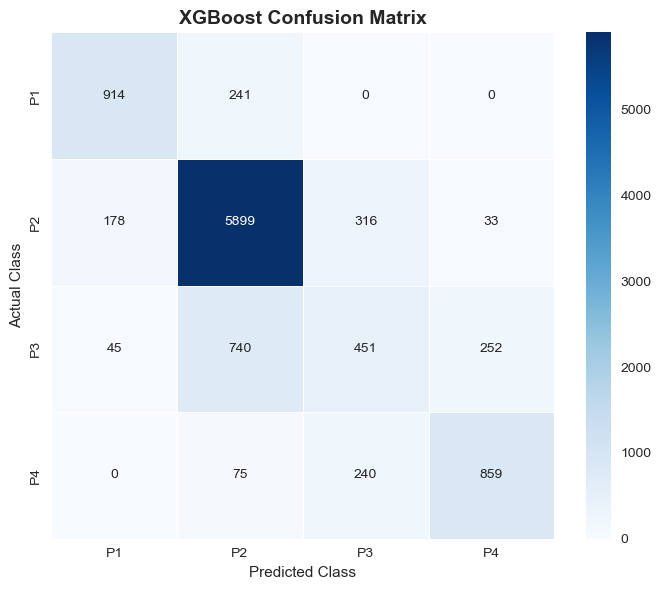

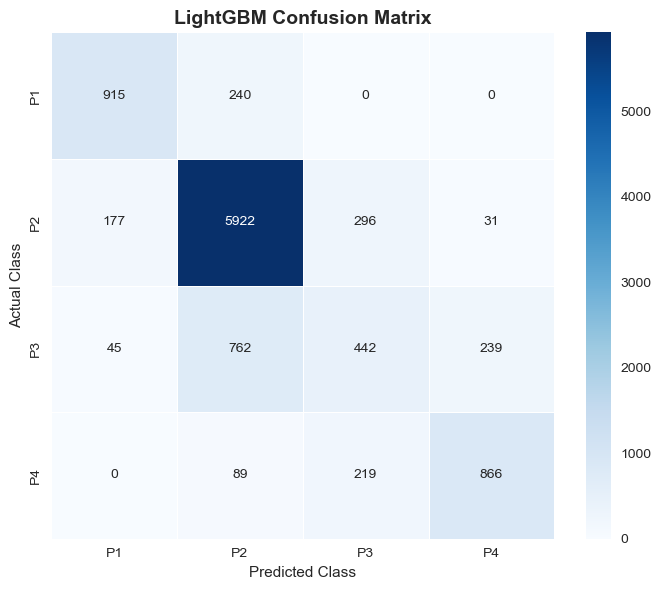

In [18]:
plot_confusion_matrix(
    xgb_cm,
    "XGBoost Confusion Matrix"
)

plot_confusion_matrix(
    lgbm_cm,
    "LightGBM Confusion Matrix"
)

In [19]:
# ============================================================
# Row-wise Normalization
# ============================================================

xgb_cm_norm = confusion_matrix(
    y_test,
    xgb_pred,
    normalize="true"
)

lgbm_cm_norm = confusion_matrix(
    y_test,
    lgbm_pred,
    normalize="true"
)

### Plotting Normalized Matrices

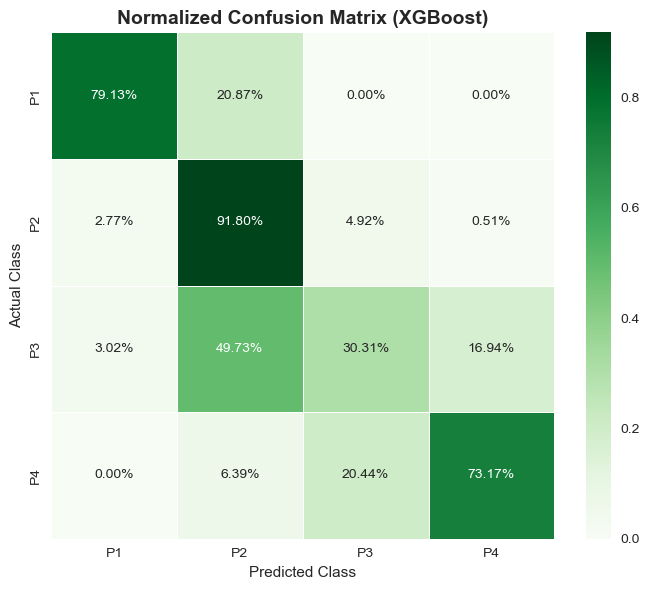

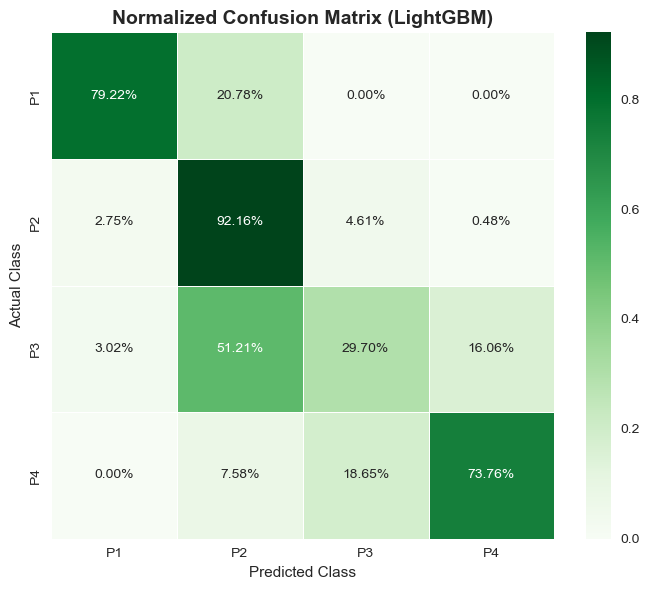

In [21]:
def plot_normalized_cm(cm, title):

    plt.figure(figsize=(7,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt=".2%",
        cmap="Greens",
        xticklabels=class_names,
        yticklabels=class_names,
        linewidths=0.5,
        cbar=True
    )

    plt.title(title, fontsize=14, fontweight="bold")

    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")

    plt.tight_layout()
    plt.show()

plot_normalized_cm(
    xgb_cm_norm,
    "Normalized Confusion Matrix (XGBoost)"
)

plot_normalized_cm(
    lgbm_cm_norm,
    "Normalized Confusion Matrix (LightGBM)"
)

**Why use a normalized confusion matrix?**

- The normalized confusion matrix expresses each row as percentages rather than raw counts.

For example, instead of seeing:

P3 → P2 = 920 borrowers

we can interpret it as:

- 62% of actual P3 borrowers were predicted as P2.

`This makes it much easier to compare performance across classes of different sizes.`

**Observations**
- 1. Almost 80% of P1 Class is correctly predicted and the rest is predicted as P2, showing that our model sometimes predict the P1 class consumer as P2 class.
- The model never predicts a low-risk borrower as a high-risk borrower.
                                                                                                                                                                                

- 2. Almost 93% of P2 Class is correctly predicted, which shows that our model is highly accurate to predict the sufficiently available data.


- 3. Now this is the trickiest thing, Almost 51% of P3 Class consumers are predicted as P2 class which implies our model predicted the less risk on those consumers which were actually more risky, and also predicts 16% into P4 class also.
- P3 is the transition zone between medium-risk and high-risk borrowers.


- 4. And the actual riskiest class P4 is predicted almost 74% times accurately.
- The absence of P4 → P1 errors is particularly reassuring.

### ***ROC-AUC Curve Analysis***

While the confusion matrix evaluates predictions at a single decision threshold, the Receiver Operating Characteristic (ROC) curve measures the model's ability to distinguish between classes across all possible classification thresholds.

For this multi-class credit risk classification problem, we adopt the One-vs-Rest (OvR) strategy, where each credit risk grade is treated as the positive class against all remaining classes.

The Area Under the ROC Curve (ROC-AUC) summarizes the model's discriminative ability:

- AUC = 1.0 indicates perfect discrimination.
- AUC = 0.5 indicates random guessing.

Higher ROC-AUC values indicate better separation between borrowers belonging to different internal risk grades.

In [22]:
# ============================================================
# Prepare Labels for Multi-class ROC
# ============================================================

from sklearn.preprocessing import label_binarize

classes = np.unique(y_test)

y_test_bin = label_binarize(
    y_test,
    classes=classes
)

print("Shape:", y_test_bin.shape)

Shape: (10243, 4)


**What is label_binarize and what does it do? And Why do we need it?**
- label_binarize transforms a multiclass labels into multiple binary labels.
for example, if our Target variable is [0,1,3,2] it gets converted into a matrix of 4 columns 
[
    [1,0,0,0],
    [0,1,0,0],
    [0,0,0,1],
    [0,0,1,0]
]

This helps us to compare the each class separately like if we can compare OneVsRest -> is the class P1?
so only P1 is Yes and rest all are No

### ROC-AUC Curve Function

In [23]:
from sklearn.metrics import roc_curve, auc
class_names = ["P1","P2","P3","P4"]
def plot_multiclass_roc(y_true_bin, y_score, class_names, title):

    plt.figure(figsize=(9,7))

    for i, class_name in enumerate(class_names):

        fpr, tpr, _ = roc_curve(
            y_true_bin[:, i],
            y_score[:, i]
        )

        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            lw=2,
            label=f"{class_name} (AUC = {roc_auc:.3f})"
        )

    plt.plot(
        [0,1],
        [0,1],
        linestyle="--",
        color="black",
        alpha=0.6
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title(title, fontsize=14, fontweight="bold")

    plt.legend(loc="lower right")

    plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.show()

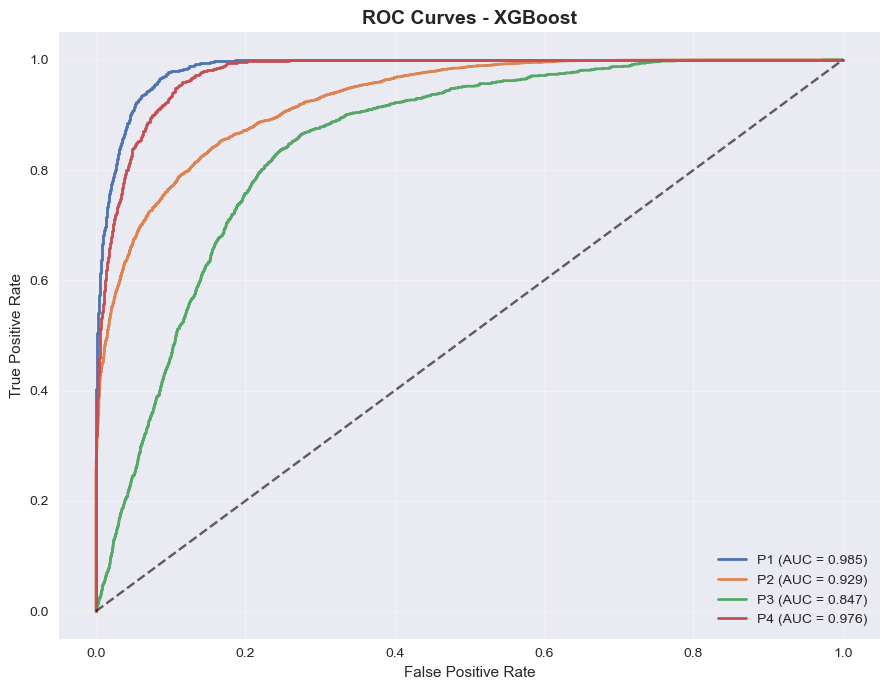

In [24]:
# Plot XGBoost

plot_multiclass_roc(
    y_test_bin,
    xgb_proba,
    class_names,
    "ROC Curves - XGBoost"
)

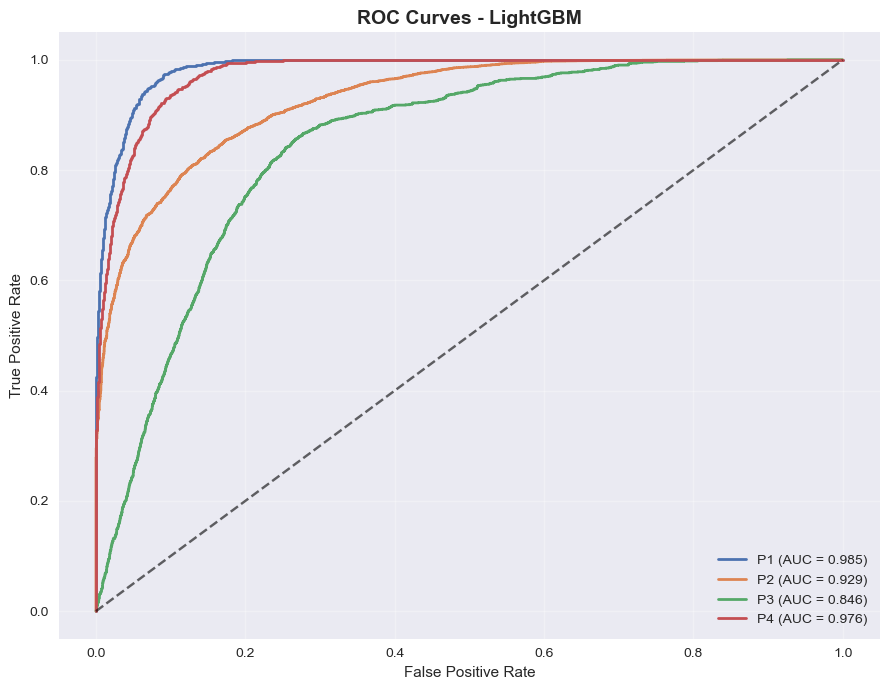

In [25]:
# PLot LightGBM
plot_multiclass_roc(
    y_test_bin,
    lgbm_proba,
    class_names,
    "ROC Curves - LightGBM"
)

### Class-Wise ROC-AUC Table

In [26]:
from sklearn.metrics import roc_auc_score

xgb_auc = {}
lgbm_auc = {}

for i, cls in enumerate(class_names):

    xgb_auc[cls] = roc_auc_score(
        y_test_bin[:, i],
        xgb_proba[:, i]
    )

    lgbm_auc[cls] = roc_auc_score(
        y_test_bin[:, i],
        lgbm_proba[:, i]
    )

roc_table = pd.DataFrame({
    "XGBoost": xgb_auc,
    "LightGBM": lgbm_auc
}).T.round(4)

roc_table

,P1,P2,P3,P4
XGBoost,0.9851,0.9288,0.8474,0.9758
LightGBM,0.9849,0.9287,0.8459,0.9756


**All four classes have ROC-AUC > 0.84, with three classes exceeding 0.92.**

- This is where combining the ROC analysis with the confusion matrix gives us a much deeper understanding.

Earlier, we saw:

`P3 Recall ≈ 30%`
                                                                                                                
`P3 F1 ≈ 0.36`

At first glance, that seems poor.

However, `P3 ROC-AUC` is approximately `0.85`.

**What does this mean?**

It suggests that the model can distinguish P3 from the other classes reasonably well, but at the current decision threshold, many P3 observations are assigned to neighboring classes (primarily P2).

In other words:

The issue is not that the model cannot recognize P3; rather, it is less confident when making the final class assignment.

This is a subtle but important distinction.

### `Why This Section Matters`

**The confusion matrix showed what happens at one threshold.**

***The ROC curves answer a different question:***

- If we changed the classification threshold, how well could the model separate each risk grade?

For example:

A low recall for P3 may still coincide with a high AUC, indicating that the model ranks P3 borrowers well, but the default decision threshold is not optimal.
Conversely, both a low recall and a low AUC suggest that the class is intrinsically difficult to distinguish.

This distinction is important for understanding whether performance limitations arise from decision thresholds or from overlapping class distributions.

### **Business Interpretation (IFRS 9)**

From a credit risk perspective:

The model demonstrates excellent discriminatory power for the safest (P1) and riskiest (P4) borrower groups.
These are the segments where accurate differentiation is most valuable for internal credit grading and downstream Probability of Default (PD) estimation.
While the intermediate-risk class (P3) remains more challenging, its ROC-AUC suggests that the underlying probability estimates still contain useful ranking information.

=========================================================================================================================

### ***Prediction Confidence Analysis***
How confident was the model when it made each prediction?

- In practical credit risk systems, the predicted class alone is often insufficient. The confidence associated with each prediction is equally important.

- Prediction confidence represents the probability assigned by the model to its predicted class.

**This analysis helps answer the following questions:**

- How confident is the model in its predictions?
- Are incorrect predictions associated with lower confidence?
- Can confidence scores be used to identify uncertain borrowers for manual review?

Understanding prediction confidence improves model transparency and supports more informed decision-making in production environments.

In [27]:
# Confidence of a prediction is simply the highest probability assigned to that class.
# ============================================================
# Prediction Confidence
# ============================================================

xgb_confidence = np.max(xgb_proba, axis=1)
lgbm_confidence = np.max(lgbm_proba, axis=1)

print(xgb_confidence[:5])
print(lgbm_confidence[:5])

[0.62493175 0.53112805 0.61792684 0.91606104 0.5309855 ]
[0.66098985 0.49085633 0.59052799 0.90871941 0.51334653]


### Confidence Distribution

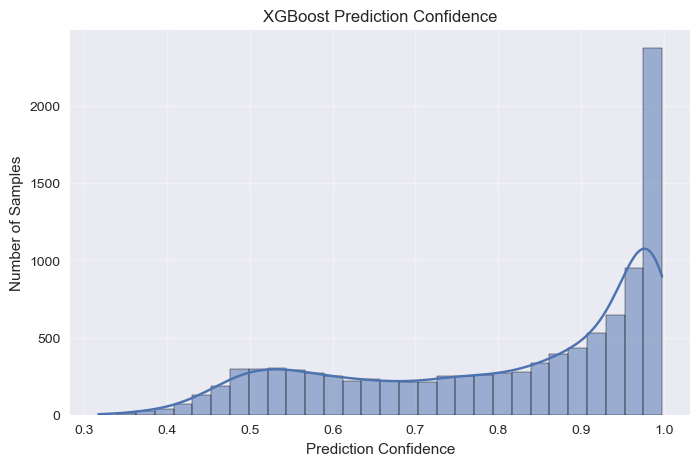

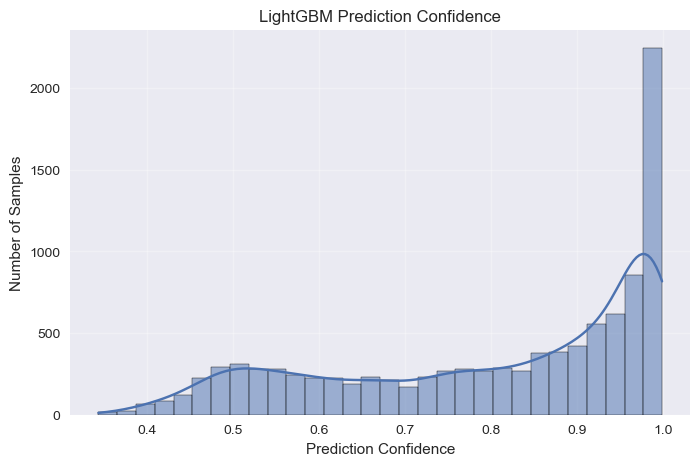

In [29]:
def plot_confidence_distribution(confidence, model_name):

    plt.figure(figsize=(8,5))

    sns.histplot(
        confidence,
        bins=30,
        kde=True
    )

    plt.xlabel("Prediction Confidence")
    plt.ylabel("Number of Samples")
    plt.title(f"{model_name} Prediction Confidence")

    plt.grid(alpha=0.3)

    plt.show()

plot_confidence_distribution(
    xgb_confidence,
    "XGBoost"
)

plot_confidence_distribution(
    lgbm_confidence,
    "LightGBM"
)

- We see that most of the predicted probabilities are above 0.9 showing that model is pretty confident in it's predictions, but it is highly left skewed, suggesting that there are some data where model is not very confident in predicting the class.

### Correct VS Incorrect Predictions

In [30]:
# Correct predictions
xgb_correct = xgb_confidence[xgb_pred == y_test]
xgb_wrong = xgb_confidence[xgb_pred != y_test]

lgbm_correct = lgbm_confidence[lgbm_pred == y_test]
lgbm_wrong = lgbm_confidence[lgbm_pred != y_test]

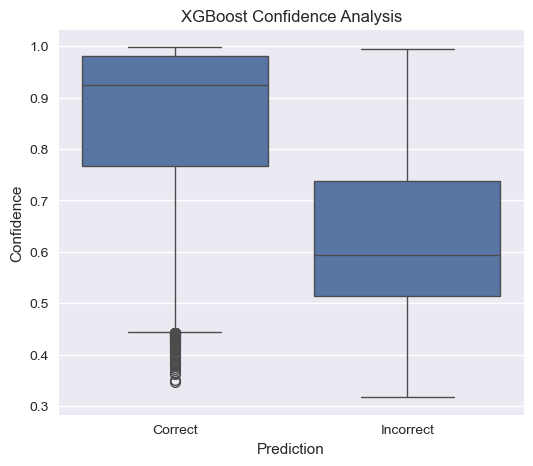

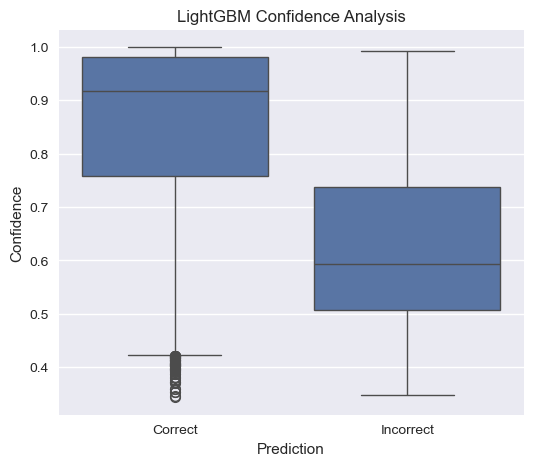

In [32]:
def confidence_boxplot(correct, wrong, model):

    df = pd.DataFrame({
        "Confidence": np.concatenate([correct, wrong]),
        "Prediction": (
            ["Correct"] * len(correct)
            +
            ["Incorrect"] * len(wrong)
        )
    })

    plt.figure(figsize=(6,5))

    sns.boxplot(
        data=df,
        x="Prediction",
        y="Confidence"
    )

    plt.title(f"{model} Confidence Analysis")

    plt.show()

confidence_boxplot(
    xgb_correct,
    xgb_wrong,
    "XGBoost"
)

confidence_boxplot(
    lgbm_correct,
    lgbm_wrong,
    "LightGBM"
)

### Numerical Summary

In [33]:
summary = pd.DataFrame({
    "Model": ["XGBoost", "LightGBM"],
    "Mean Confidence": [
        xgb_confidence.mean(),
        lgbm_confidence.mean()
    ],
    "Correct Mean": [
        xgb_correct.mean(),
        lgbm_correct.mean()
    ],
    "Incorrect Mean": [
        xgb_wrong.mean(),
        lgbm_wrong.mean()
    ]
})

summary.round(4)

,Model,Mean Confidence,Correct Mean,Incorrect Mean
0,XGBoost,0.8073,0.8539,0.6286
1,LightGBM,0.8025,0.8486,0.6235


**This is one of the most excellent results in our entire notebook-**

- Both models have an average confidence of approximately 80%.
This indicates that, on average, the models assign a substantial probability to their predicted class rather than making highly uncertain predictions.

- Models are much more confident in predicting the correct predictions, i.e they were highly confident about their predictions and those came out to be True.

- And again, the models were low in confidence in predicting the classes and they were actually false.

- This means they are not blindly confident. Instead, their confidence decreases when they are more likely to make an error.

### ***ERROR ANALYSIS***

- Overall performance metrics provide a high-level assessment of model quality, but they do not explain the nature of prediction errors.

- Error analysis investigates the model's misclassifications to identify systematic patterns and understand where the model struggles.

The objectives of this section are:

- Quantify the total number of prediction errors.
- Identify the most common misclassification patterns.
- Examine the confidence associated with incorrect predictions.
- Inspect representative misclassified samples.
- Assess whether the observed errors are acceptable from a credit risk perspective.

This analysis provides valuable insight into the practical limitations of the model before deployment.

**1. Number of Incorrect Predictions**

In [34]:
# ============================================================
# Number of Incorrect Predictions
# ============================================================

xgb_errors = xgb_pred != y_test
lgbm_errors = lgbm_pred != y_test

print("=" * 60)
print("XGBoost")
print("=" * 60)

print(f"Correct Predictions : {np.sum(~xgb_errors):,}")
print(f"Incorrect Predictions : {np.sum(xgb_errors):,}")
print(f"Error Rate : {xgb_errors.mean():.2%}")

print()

print("=" * 60)
print("LightGBM")
print("=" * 60)

print(f"Correct Predictions : {np.sum(~lgbm_errors):,}")
print(f"Incorrect Predictions : {np.sum(lgbm_errors):,}")
print(f"Error Rate : {lgbm_errors.mean():.2%}")

XGBoost
Correct Predictions : 8,123
Incorrect Predictions : 2,120
Error Rate : 20.70%

LightGBM
Correct Predictions : 8,145
Incorrect Predictions : 2,098
Error Rate : 20.48%


**2. Most Common Misclassification Patterns**

In [35]:
# ============================================================
# Misclassification Patterns
# ============================================================

def error_summary(y_true, y_pred, class_names):

    errors = pd.DataFrame({
        "Actual": y_true,
        "Predicted": y_pred
    })

    errors = errors[
        errors["Actual"] != errors["Predicted"]
    ]

    errors["Actual"] = errors["Actual"].map(
        dict(enumerate(class_names))
    )

    errors["Predicted"] = errors["Predicted"].map(
        dict(enumerate(class_names))
    )

    summary = (
        errors
        .groupby(["Actual","Predicted"])
        .size()
        .reset_index(name="Count")
        .sort_values("Count", ascending=False)
    )

    return summary

In [36]:
xgb_error_summary = error_summary(
    y_test,
    xgb_pred,
    class_names
)

lgbm_error_summary = error_summary(
    y_test,
    lgbm_pred,
    class_names
)

print("XGBoost")
display(xgb_error_summary)

print()

print("LightGBM")
display(lgbm_error_summary)

XGBoost


,Actual,Predicted,Count
5,P3,P2,740
2,P2,P3,316
6,P3,P4,252
0,P1,P2,241
8,P4,P3,240
1,P2,P1,178
7,P4,P2,75
4,P3,P1,45
3,P2,P4,33



LightGBM


,Actual,Predicted,Count
5,P3,P2,762
2,P2,P3,296
0,P1,P2,240
6,P3,P4,239
8,P4,P3,219
1,P2,P1,177
7,P4,P2,89
4,P3,P1,45
3,P2,P4,31


- This shows that most of the errors occurred because of misclassifying P3 and P4 classes by both the models and this was because of the big imbalance in our data

In [37]:
# ============================================================
# Inspect Misclassified Samples
# ============================================================

def misclassified_samples(
    X_test,
    y_true,
    y_pred,
    confidence,
    class_names,
    n=10
):

    df = X_test.copy()

    df["Actual"] = y_true.values
    df["Predicted"] = y_pred

    df["Actual"] = df["Actual"].map(
        dict(enumerate(class_names))
    )

    df["Predicted"] = df["Predicted"].map(
        dict(enumerate(class_names))
    )

    df["Confidence"] = confidence

    df = df[
        df["Actual"] != df["Predicted"]
    ]

    return (
        df
        .sort_values(
            "Confidence",
            ascending=False
        )
        .head(n)
    )

In [38]:
display(
    misclassified_samples(
        X_test,
        y_test,
        lgbm_pred,
        lgbm_confidence,
        class_names
    )
)

,pct_tl_open_L6M,pct_tl_closed_L6M,Tot_TL_closed_L12M,pct_tl_open_L12M,pct_tl_closed_L12M,Tot_Missed_Pmnt,CC_TL,Home_TL,PL_TL,Secured_TL,...,first_prod_enq2_others,last_prod_enq2_AL,last_prod_enq2_CC,last_prod_enq2_ConsumerLoan,last_prod_enq2_HL,last_prod_enq2_PL,last_prod_enq2_others,Actual,Predicted,Confidence
6519,0.833,0.333,2,1.000,0.333,1,0,0,1,3,...,0,0,0,1,0,0,0,P3,P4,0.992496
499,1.000,0.000,0,1.000,0.000,1,0,0,0,1,...,1,0,0,0,0,0,1,P3,P2,0.978217
9982,0.000,0.500,2,0.000,0.500,0,0,0,0,1,...,0,0,0,0,0,0,1,P3,P2,0.975045
2334,0.750,0.250,1,0.750,0.250,3,0,0,0,2,...,1,0,0,0,0,0,1,P3,P2,0.973677
2716,0.000,0.500,1,0.500,0.500,0,0,0,0,2,...,1,0,0,0,0,0,1,P3,P2,0.971818
6703,0.000,0.000,4,0.143,0.571,1,0,0,0,7,...,1,0,0,0,0,0,1,P3,P2,0.971662
4120,1.000,0.000,0,1.000,0.000,0,0,0,0,0,...,0,0,0,1,0,0,0,P3,P2,0.969829
9973,0.200,0.200,1,0.200,0.200,0,0,0,0,5,...,1,0,0,0,0,0,1,P2,P1,0.969088
8387,0.000,0.000,0,0.000,0.000,0,0,0,0,1,...,1,0,0,0,0,0,1,P3,P2,0.969087
19,0.000,0.143,2,0.571,0.286,1,0,0,0,1,...,0,0,0,0,0,1,0,P3,P2,0.968590


- These are the TOP 10 results where our model predicted WRONG with the highest confidence.

===========================================================================================================================

# ***Overall Model Validation Summary***

## Objective

This notebook performed a comprehensive evaluation of the final tuned XGBoost and LightGBM models developed for the multiclass credit risk rating system.

The evaluation extended beyond conventional performance metrics to assess class-wise behaviour, prediction confidence, and error characteristics, providing a holistic understanding of model reliability before explainability and deployment.

---

## Key Findings

### Overall Predictive Performance

Both XGBoost and LightGBM achieved strong predictive performance on the held-out test dataset.

- Classification Accuracy ≈ **79.5%**
- Weighted F1-Score ≈ **0.78**
- Weighted ROC-AUC ≈ **0.93**

The performance difference between the two models was minimal, with LightGBM demonstrating a slight advantage in classification metrics while XGBoost achieved a marginally higher ROC-AUC. Overall, both models provide robust predictive capability for internal credit risk classification.

---

### Class-wise Performance

Performance varied across the four internal credit risk grades.

- **P1 (Lowest Risk):** High precision and recall, indicating reliable identification of low-risk borrowers.
- **P2 (Low–Moderate Risk):** Best-performing class, benefiting from both clear separation and larger sample representation.
- **P3 (Intermediate Risk):** Most challenging class, with substantially lower recall due to overlap with neighbouring risk grades.
- **P4 (Highest Risk):** Strong predictive performance, demonstrating the model's ability to identify high-risk borrowers effectively.

The reduced performance on P3 appears to reflect overlapping borrower characteristics rather than instability of the learning algorithm.

---

### Confusion Matrix Analysis

The confusion matrix revealed that prediction errors predominantly occurred between neighbouring credit risk grades.

The most frequent misclassifications involved transitions such as:

- P1 ↔ P2
- P2 ↔ P3
- P3 ↔ P4

Importantly, extreme misclassifications between the safest and riskiest borrower groups (e.g., P1 → P4 or P4 → P1) were virtually absent.

This indicates that the model successfully preserves the ordinal structure of borrower risk.

---

### Discriminative Ability

ROC-AUC analysis demonstrated excellent class discrimination.

- P1 and P4 achieved near-perfect discrimination.
- P2 also exhibited excellent separability.
- Although P3 recorded the lowest ROC-AUC, it remained within the "good" discrimination range.

These findings suggest that the predicted class probabilities retain meaningful ranking information, supporting their future use in downstream Probability of Default (PD) mapping.

---

### Prediction Confidence

Prediction confidence analysis demonstrated that both models assign substantially higher confidence to correct predictions than to incorrect predictions.

Average confidence was approximately:

- **85%** for correct predictions.
- **63%** for incorrect predictions.

This behaviour indicates that the models appropriately express uncertainty, providing opportunities for confidence-based decision support and potential manual review of low-confidence cases.

---

### Error Analysis

Detailed error analysis confirmed that model failures are concentrated within the intermediate-risk borrower population.

Most incorrect predictions occurred between adjacent risk grades, particularly involving the P3 class.

These error patterns are consistent with the expected overlap between neighbouring borrower risk profiles and do not indicate systematic model instability.

---

## Overall Assessment

The extensive validation demonstrates that the tuned gradient boosting models provide reliable multiclass credit risk classification with strong discrimination across borrower risk grades.

The models preserve the natural ordering of internal credit ratings, exhibit meaningful confidence estimates, and avoid severe cross-grade misclassifications.

Collectively, these characteristics indicate that the selected models are suitable candidates for integration into the subsequent explainability and IFRS 9 Expected Credit Loss (ECL) framework.

---

## Next Phase

Having established the predictive reliability of the selected models, the next chapter focuses on model explainability using SHAP (SHapley Additive exPlanations).

The explainability phase will investigate:

- Business interpretation of SHAP values within the context of IFRS 9 credit risk assessment

This final stage will improve model transparency and support explainable, defensible credit risk decisions before deployment.